# HW 4

## Task 1

For this problem I will be using [1], which is a dataset of air quality indicators. I will attempt to use recurrent neural networks to forecast carbon monoxide levels at the end of every 24 hour interval. This dataset requires substantial preprocessing as significant numbers of datapoint entries are missing.

https://archive.ics.uci.edu/dataset/360/air+quality

In [149]:
import pandas as pd
import numpy as np

In [150]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [151]:
import random
import os
import torch

def seed_everything(seed: int = 67):
 random.seed(seed)
 np.random.seed(seed)
 os.environ["PYTHONHASHSEED"] = str(seed)
 torch.manual_seed(seed)
 torch.cuda.manual_seed_all(seed)
 torch.backends.cudnn.benchmark = False
 torch.backends.cudnn.deterministic = True

seed_everything(42)
rng = np.random.default_rng(42)

In [152]:
df = pd.read_excel("drive/MyDrive/HW4_dataset/AirQualityUCI.xlsx")
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10,18:00:00,2.6,1360.00,150,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.60,48.875001,0.757754
1,2004-03-10,19:00:00,2.0,1292.25,112,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.30,47.700000,0.725487
2,2004-03-10,20:00:00,2.2,1402.00,88,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.90,53.975000,0.750239
3,2004-03-10,21:00:00,2.2,1375.50,80,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.00,60.000000,0.786713
4,2004-03-10,22:00:00,1.6,1272.25,51,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.15,59.575001,0.788794


In [153]:
print("MISSINGNESS SUMMARY:")
print(f"Total samples: {len(df)}")

for label in df.keys():
  missing_cnt = np.count_nonzero(df[label] == -200)
  print(f"{label.ljust(13)} | Missing - {str(missing_cnt).ljust(8)} ({missing_cnt/len(df)*100:.2f} %)")


MISSINGNESS SUMMARY:
Total samples: 9357
Date          | Missing - 0        (0.00 %)
Time          | Missing - 0        (0.00 %)
CO(GT)        | Missing - 1683     (17.99 %)
PT08.S1(CO)   | Missing - 366      (3.91 %)
NMHC(GT)      | Missing - 8443     (90.23 %)
C6H6(GT)      | Missing - 366      (3.91 %)
PT08.S2(NMHC) | Missing - 366      (3.91 %)
NOx(GT)       | Missing - 1639     (17.52 %)
PT08.S3(NOx)  | Missing - 366      (3.91 %)
NO2(GT)       | Missing - 1642     (17.55 %)
PT08.S4(NO2)  | Missing - 366      (3.91 %)
PT08.S5(O3)   | Missing - 366      (3.91 %)
T             | Missing - 366      (3.91 %)
RH            | Missing - 366      (3.91 %)
AH            | Missing - 366      (3.91 %)


As shown, we are missing substantial quantities of values for certain features. We will drop the non-methane hydrocarbons (NMHC(GT)) column, as over 90 of the datapoints are missing. We will utilize Pandas interpolate for all other features with missing values.

In [154]:
df = df.drop(columns=["NMHC(GT)"])
df.replace(-200, np.nan, inplace=True)
for label in df.keys():
  if label in ("Date", "Time"):
    continue
  df[label] = df[label].interpolate(method="polynomial", order=2)

df.head()

,Date,Time,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10,18:00:00,2.6,1360.00,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.60,48.875001,0.757754
1,2004-03-10,19:00:00,2.0,1292.25,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.30,47.700000,0.725487
2,2004-03-10,20:00:00,2.2,1402.00,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.90,53.975000,0.750239
3,2004-03-10,21:00:00,2.2,1375.50,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.00,60.000000,0.786713
4,2004-03-10,22:00:00,1.6,1272.25,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.15,59.575001,0.788794


Doing a quick sanity check for missingness after column drop and imputation:

In [155]:
print("MISSINGNESS SANITY CHECK:")
print(f"Total samples: {len(df)}")

for label in df.keys():
  missing_cnt = np.count_nonzero(df[label] == np.nan)
  print(f"{label.ljust(13)} | Missing - {str(missing_cnt).ljust(8)} ({missing_cnt/len(df)*100:.2f} %)")

df.head()

MISSINGNESS SANITY CHECK:
Total samples: 9357
Date          | Missing - 0        (0.00 %)
Time          | Missing - 0        (0.00 %)
CO(GT)        | Missing - 0        (0.00 %)
PT08.S1(CO)   | Missing - 0        (0.00 %)
C6H6(GT)      | Missing - 0        (0.00 %)
PT08.S2(NMHC) | Missing - 0        (0.00 %)
NOx(GT)       | Missing - 0        (0.00 %)
PT08.S3(NOx)  | Missing - 0        (0.00 %)
NO2(GT)       | Missing - 0        (0.00 %)
PT08.S4(NO2)  | Missing - 0        (0.00 %)
PT08.S5(O3)   | Missing - 0        (0.00 %)
T             | Missing - 0        (0.00 %)
RH            | Missing - 0        (0.00 %)
AH            | Missing - 0        (0.00 %)


,Date,Time,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10,18:00:00,2.6,1360.00,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.60,48.875001,0.757754
1,2004-03-10,19:00:00,2.0,1292.25,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.30,47.700000,0.725487
2,2004-03-10,20:00:00,2.2,1402.00,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.90,53.975000,0.750239
3,2004-03-10,21:00:00,2.2,1375.50,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.00,60.000000,0.786713
4,2004-03-10,22:00:00,1.6,1272.25,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.15,59.575001,0.788794


## Preprocessing

In [156]:
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=["Date", "Time"])

scaler = StandardScaler()
X = scaler.fit_transform(X)

print("X shape:", X.shape)

X shape: (9357, 12)


In [157]:
from sklearn.model_selection import train_test_split
import torch

SEQUENCE_LENGTH = 24

X_sequences = list()
Y_sequences = list()


#in this arrangement the features for the last value will
#be discarded

for i in range(SEQUENCE_LENGTH, len(X)): # Corrected loop start index
  X_sequences.append(X[i-SEQUENCE_LENGTH:i])
  Y_sequences.append(X[i][0])

X_sequences=np.array(X_sequences)
Y_sequences=np.array(Y_sequences)

X_train, X_val, Y_train, Y_val = train_test_split(X_sequences,
                                                    Y_sequences,
                                                    random_state = 67,
                                                    test_size=0.3)

X_test, X_dev, Y_test, Y_dev = train_test_split(X_val, Y_val,
                                                random_state = 67,
                                                test_size=0.5)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
Y_train = torch.tensor(Y_train, dtype=torch.float32).to(device).unsqueeze(1)
X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
Y_test = torch.tensor(Y_test, dtype=torch.float32).to(device).unsqueeze(1)
X_dev = torch.tensor(X_dev, dtype=torch.float32).to(device)
Y_dev = torch.tensor(Y_dev, dtype=torch.float32).to(device).unsqueeze(1)


print(X_train.shape)

torch.Size([6533, 24, 12])


## TRAINING

For training, I will be using Pytorch's implementation of the recurrent neural network, as well as their implementation of LSTM and GRU. The Pytorch RNN uses tanh as an activation function between layers. Because my problem is a regression problem, I will not need an activation function in my output layer. I intend to use mean absolute error (L1 loss) as my loss function because my data is, and a significant part of it is synthetic interpolation, which would exessively penalize me if I were to use mean squred error.

In [158]:
from torch import nn
import torch

class RecurrentNeuralNetwork(nn.Module):
  def __init__(self, n_features, n_hidden, n_output, loss_function = nn.L1Loss):
    super().__init__()
    self.hidden_size = n_hidden

    self.rnn = nn.RNN(input_size=n_features,
                      hidden_size=n_hidden,
                      num_layers=1,
                      batch_first=True)

    self.fc = nn.Linear(n_hidden, n_output)
    self.loss_function = loss_function()
    self.optimizer = torch.optim.Adam(self.parameters(), lr=0.01, weight_decay=0.01)


  def forward(self, x):
    rnn_out, h_n = self.rnn(x)

    last_output = rnn_out[:, -1, :]
    output = self.fc(last_output)

    return output

  def train_step(self, X, y):
    self.train()

    #forward propagation
    pred = self(X)
    loss = self.loss_function(pred, y)

    #back propagation
    loss.backward()
    self.optimizer.step()
    self.optimizer.zero_grad()

    return loss

In [159]:
import matplotlib.pyplot as plt

def plot_dev_train_loss(dev_loss, train_loss, title = ""):
  plt.plot(train_loss, label='train')
  plt.plot(dev_loss, label='dev')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.title(title)
  plt.legend()
  plt.show()

In [160]:
epochs = 100
n_features = X_train.shape[2]
n_hidden = 64
n_output = 1

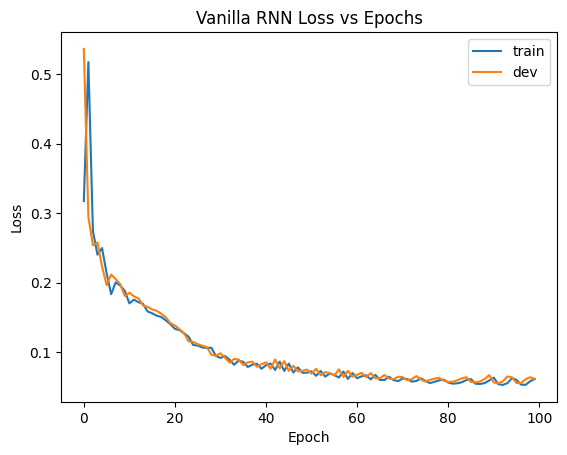



Test loss: 0.060779910534620285


In [161]:
model = RecurrentNeuralNetwork(n_features, n_hidden, n_output)
model.to(device)

train_losses = list()
test_losses = list()

for t in range(epochs):
  loss = model.train_step(X_train, Y_train)
  train_losses.append(loss.item())

  model.eval()
  with torch.no_grad():
    pred = model(X_dev)
    dev_loss = model.loss_function(pred, Y_dev)
    test_losses.append(dev_loss.item())

plot_dev_train_loss(test_losses, train_losses, "Vanilla RNN Loss vs Epochs")

test_loss = model.loss_function(model(X_test), Y_test)
print("\n\nTest loss:", test_loss.item())

Discussion: The performance of the RNN is quite good both in the dev and training sets. The descent seems to be "jerkier", however. This is likely due to the vanishing gradient.

## Part 2

I will implement LSTM and GRU as subclasses of my RNN class.

In [162]:
class LSTMNetwork(RecurrentNeuralNetwork):
  def __init__(self, n_features, n_hidden, n_output, loss_function = nn.L1Loss):
    super().__init__(n_features, n_hidden, n_output, loss_function)
    self.rnn = nn.LSTM(input_size=n_features,
                      hidden_size=n_hidden,
                      num_layers=1,
                      batch_first=True)



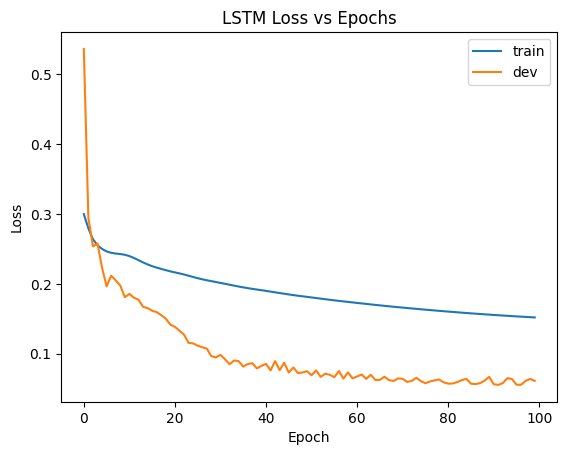



Test loss: 0.16586418449878693


In [163]:
model = LSTMNetwork(n_features, n_hidden, n_output)
model.to(device)

train_losses = list()
dev_losses = list()

for t in range(epochs):
  loss = model.train_step(X_train, Y_train)
  train_losses.append(loss.item())

  model.eval()
  with torch.no_grad():
    pred = model(X_dev)
    dev_loss = model.loss_function(pred, Y_dev)
    dev_losses.append(dev_loss.item())

plot_dev_train_loss(test_losses, train_losses, "LSTM Loss vs Epochs")

test_loss = model.loss_function(model(X_test), Y_test)
print("\n\nTest loss:", test_loss.item())

Strange...

In [164]:
class GRUNetwork(RecurrentNeuralNetwork):
  def __init__(self, n_features, n_hidden, n_output, loss_function = nn.L1Loss):
    super().__init__(n_features, n_hidden, n_output, loss_function)
    self.rnn = nn.GRU(input_size=n_features,
                      hidden_size=n_hidden,
                      num_layers=1,
                      batch_first=True)

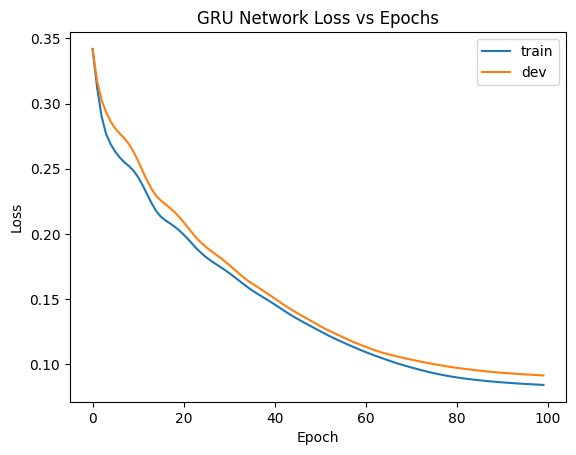



Test loss: 0.08917335420846939


In [165]:
model = GRUNetwork(n_features, n_hidden, n_output)
model.to(device)

train_losses = list()
test_losses = list()

for t in range(epochs):
  loss = model.train_step(X_train, Y_train)
  train_losses.append(loss.item())

  model.eval()
  with torch.no_grad():
    pred = model(X_dev)
    dev_loss = model.loss_function(pred, Y_dev)
    test_losses.append(dev_loss.item())

plot_dev_train_loss(test_losses, train_losses, "GRU Network Loss vs Epochs")

test_loss = model.loss_function(model(X_test), Y_test)
print("\n\nTest loss:", test_loss.item())

## Discussion:

My perofmance for the RNN variants were strange. The GRU network appears to outperform the LSTM network, which runs counter to expectations, as LSTMs are 3 gate architectures. Likewise, LSTM dev loss ended up being substantially lower than training loss. I am not sure why this happened. Further, the vanilla RNN outperformed both.

The behavior otherwise is expected. The training curves for both LSTM and GRU were substantially smoother than the loss and training curves for the vanilla RNN.

## Part 3

For my purposes, I probably could use a regular MLP if the task was simply predicting the CO levels on a given day, as we would be mapping chemical indicators with CO level labels. This would be a standard regression problem. However, we'd lose out of capturing temporal signals from the 24 hour time window, which the recurrent neural network variants are able to capture.

# Task 2

##Part 1:

For this task, I will use fastText. I chose fastText because it is the most powerful of the word-level models, distinguishing itself from GloVe and Word2Vec by its sensitivity to subword features. I also chose it over BERT because we will be dealing with word-level tasks. BERT is a transformer-based architecture able to output dense sentence-level embeddings, which is overkill for our purposes.


fastText handles OOV implicitly due to its subword sensitivity. However, were we working with GloVe or Word2Vec, we'd most likely handle unknowns with an unknown token indicator or fallback output type like a zero-vector. One new suggestion, however, might be to train a smart helper model that predicts unknown words based on the surrounding context. This somewhat resembles the masked-token training process of BERT.

In [166]:
!pip install fasttext

In [167]:
import fasttext
from huggingface_hub import hf_hub_download
model_path = hf_hub_download(repo_id="facebook/fasttext-en-vectors", filename="model.bin")
model = fasttext.load_model(model_path)

In [168]:
# test

print(model.get_word_vector("foo").shape)
print(type(model.get_word_vector("bar")))

(300,)
<class 'numpy.ndarray'>


In [169]:
class Task2EmbeddingWrapper():
  def __init__(self, dim = 300):
    self.model = fasttext.load_model(hf_hub_download(repo_id="facebook/fasttext-en-vectors",
                                                     filename="model.bin"))
    self.dim = dim

  def get_embedding(self, word1: str = None, word2: str = None):
    emb1 = self.model.get_word_vector(word1) if word1 else None
    emb2 = self.model.get_word_vector(word2) if word2 else None

    # psuedo polymorphism handling
    if emb1 is not None and emb2 is not None:
      return emb1, emb2
    elif emb1 is not None:
      return emb1
    elif emb2 is not None:
      return emb2
    else:
      raise ValueError("No words were inputted.")


  def calc_cosine_sim(self, emb1: np.ndarray, emb2: np.ndarray):
    num = np.dot(emb1,emb2)
    denom = np.linalg.norm(emb1) * np.linalg.norm(emb2)

    return num/denom

  def batch_cosine_sim(self, word_pairs: list[list[str, str]]):
    similarities = list()

    for pair in word_pairs:
      emb1, emb2 = self.get_embedding(pair[0], pair[1])
      self.calc_cosine_sim(emb1, emb2)
      similarities.append(self.calc_cosine_sim(emb1, emb2))

    return similarities




### Demonstration of basic functionality described in part 1 and part 2:

In [170]:
wrapper = Task2EmbeddingWrapper()

#obtaining one embedding
emb1 = wrapper.get_embedding("bruh")

#obtaining two embeddings
emb2, emb3 = wrapper.get_embedding("good", "bad")

print(emb1[:10]) #outputting first 10 of embedding 1

print(wrapper.calc_cosine_sim(emb2, emb3)) # printing cosine similarity

[ 0.18916146 -0.05442639  0.08854568  0.01264028 -0.15903237 -0.2852831
  0.10058969 -0.01916669  0.07252933  0.1577766 ]
0.7517591


In [171]:
paired_examples = [["orange", "apple"],
 ["open", "closed"],
 ["school", "academy"],
 ["gradient", "descent"]]

print(wrapper.batch_cosine_sim(paired_examples)) # demonstrating BATCH functionality

[np.float32(0.5037653), np.float32(0.60873896), np.float32(0.5362037), np.float32(0.34289828)]


## Visualizing t-SNE plot:

To visualize clusters, I had ChatGPT generate 50 math words and 50 history words.

In [172]:
math_words = [
    "algebra", "geometry", "calculus", "trigonometry", "probability",
    "statistics", "vector", "matrix", "tensor", "scalar",
    "function", "variable", "equation", "inequality", "polynomial",
    "derivative", "integral", "limit", "series", "sequence",
    "logarithm", "exponent", "factorial", "permutation", "combination",
    "eigenvalue", "eigenvector", "determinant", "gradient", "divergence",
    "laplacian", "manifold", "topology", "category", "group",
    "ring", "field", "isomorphism", "homomorphism", "bijection",
    "surjection", "injection", "congruence", "modulus", "prime",
    "composite", "theorem", "lemma", "proof", "axiom"
]

history_words = [
    "empire", "dynasty", "revolution", "treaty", "colony",
    "monarchy", "republic", "constitution", "parliament", "senate",
    "feudalism", "industrialization", "imperialism", "colonization", "migration",
    "trade", "war", "alliance", "siege", "rebellion",
    "uprising", "expansion", "conquest", "exploration", "navigation",
    "archaeology", "artifact", "chronicle", "manuscript", "inscription",
    "civilization", "kingdom", "province", "territory", "frontier",
    "culture", "tradition", "religion", "mythology", "ritual",
    "economy", "taxation", "currency", "law", "reform",
    "propaganda", "nationalism", "diplomacy", "sovereignty", "succession"
]

embeddings = []
labels = 50 * [0] + 50 * [1]

for word in math_words + history_words:
  embeddings.append(wrapper.get_embedding(word))

embeddings = np.stack(embeddings)

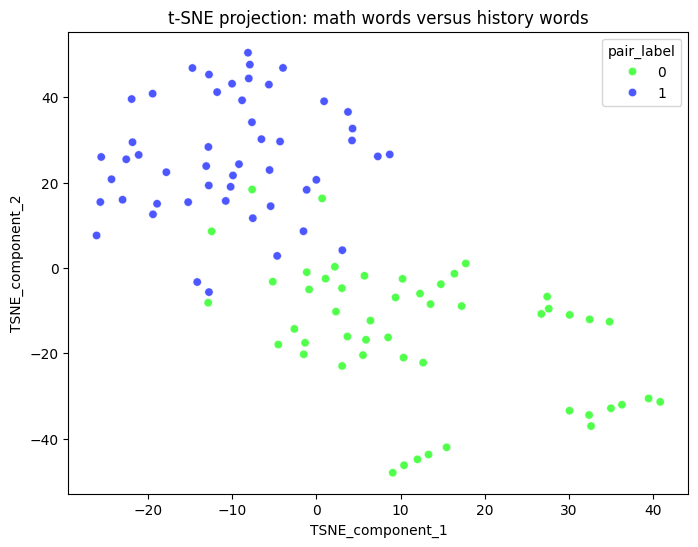

In [173]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

X_embedded = TSNE(n_components=2, learning_rate='auto',
                  init='random', perplexity=3).fit_transform(embeddings)
X_embedded.shape

df_tsne = pd.DataFrame(X_embedded, columns=['TSNE_component_1', 'TSNE_component_2'])
df_tsne['pair_label'] = labels

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='TSNE_component_1', y='TSNE_component_2',
    hue='pair_label',
    palette=sns.color_palette('hsv', n_colors=len(np.unique(labels))),
    data=df_tsne,
    legend='full',
    alpha=0.7
)
plt.title('t-SNE projection: math words versus history words')
plt.show()

### Explanation of cosine similarity:

Cosine similarity is useful because it operationalizes semantic similarity using the principle that high co-occurance indicates high similarity. Additionally, because it's a directional metric, it isn't influenced by vector magnitude, allowing comparison of common words with less common words.

### Part 3

For the dissimilarity, I will be trying to find what I'll call the antonym subspace. This is partly inspired by the "eigenslur" hypothesis [1], which suggests there exists some typical geometric transform of items in the vector space representing concept A into corresponding items in vector space representing concept B, the prototypical case being a transform of vectors representing groups into vectors representing epithets for those groups.

Rather than using the naive mean vector difference approach I initally thought of (which would fail due to the bidirectionality of antonymity), I will attempt to use PCA reduction to isolate principle components of a set of antonym difference vectors. I will then use the reconstruction magnitude of test samples as a sort of loss function, as a higher magnitude suggests a more complete reconstruction and the sample transform's better fitting into the antonym space.


[1] https://www.youtube.com/shorts/I1rquCFV7X4

In [174]:
with open("drive/MyDrive/HW4_dataset/antonym_pairs.txt", "r") as f:
  antonym_pairs = f.readlines()

with open("drive/MyDrive/HW4_dataset/synonym_pairs.txt", "r") as f:
  synonym_pairs = f.readlines()

paired_antonym_embeddings = []
paired_synonym_embeddings = []
paired_antonyms = []
paired_synonyms = []

for pair_str in antonym_pairs:
  pair = pair_str.split("-")
  word1 = pair[0].strip()
  word2 = pair[1].strip()

  paired_antonyms.append([word1, word2])

  paired_antonym_embeddings.append(wrapper.get_embedding(word1, word2))

for pair_str in synonym_pairs:
  pair = pair_str.split("-")
  word1 = pair[0].strip()
  word2 = pair[1].strip()

  paired_synonyms.append([word1, word2])

  paired_synonym_embeddings.append(wrapper.get_embedding(word1, word2))

print(len(paired_antonym_embeddings))


developer_set = paired_antonym_embeddings[:400]
test_set = paired_antonym_embeddings[400:]

424


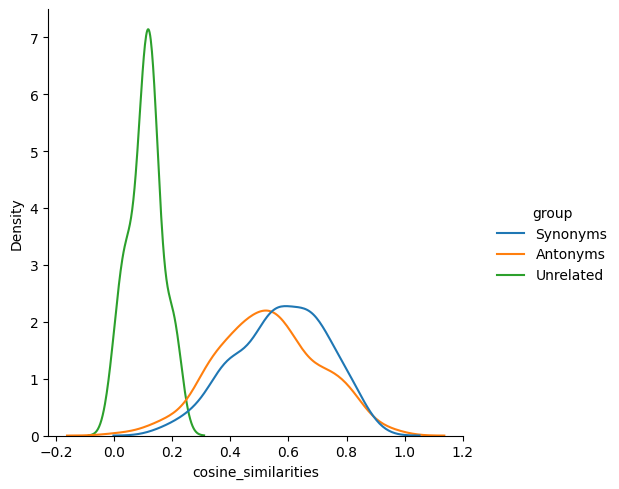

In [175]:
# Baseline visualization
import matplotlib.pyplot as plt
import seaborn as sns
import numpy
import pandas as pd # Import pandas

synonym_similarities = wrapper.batch_cosine_sim(paired_synonyms)
antonym_similarities = wrapper.batch_cosine_sim(paired_antonyms)
unrelated_words_similarities = wrapper.batch_cosine_sim(zip(math_words, history_words))
#reusing unrelated words from earlier visualization

word_similarities = synonym_similarities + antonym_similarities + unrelated_words_similarities
labels = ["Synonyms"] * len(synonym_similarities) + ["Antonyms"] * len(antonym_similarities)\
         + ["Unrelated"] * len(unrelated_words_similarities)

data = {'cosine_similarities': word_similarities, 'group': labels}
df = pd.DataFrame(data)

sns.displot(data=df, x='cosine_similarities', hue='group', kind='kde', common_norm=False, fill=False)
plt.show()

As shown, cosine similarity has a hard time distinguishing between synonyms and antonyms compared to either when compared with unrelated words.

In [176]:
from sklearn.decomposition import PCA
import numpy as np

difference_vectors = []

for pair in developer_set:
  diff_vector = pair[0] - pair[1]
  difference_vectors.append(diff_vector)

difference_vectors = np.stack(difference_vectors)

pca = PCA(n_components=100)
pca.fit(difference_vectors)
print(sum(pca.explained_variance_ratio_)*100, "percent of the variance in antonym transforms can be \
explained by the first 56 principal components.")

86.1137 percent of the variance in antonym transforms can be explained by the first 56 principal components.


PCA on antonym difference vectors shows that approximately 70% of the variance can be captured by the first 56 principal components out of 300. This suggests that antonymity transforms have a structure but that structure is dispersed between many dimensions.

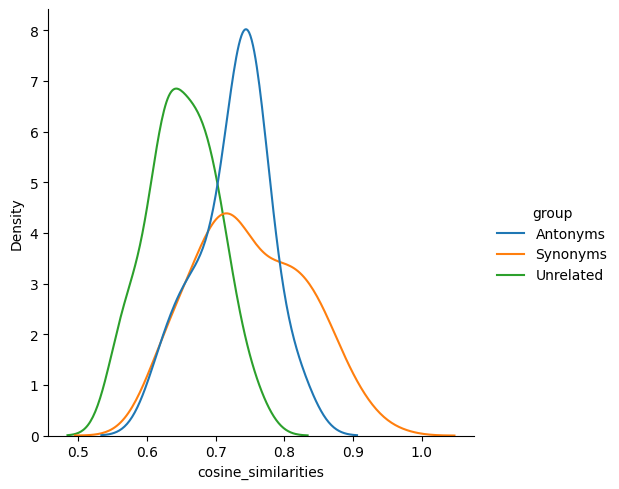

Antonym test group mean: 0.7257,
 Synonym group mean0.7498,
 Unrelated word mean 0.6518


In [177]:
test_scores = []
syno_scores = []
noise_scores = []

for pair in test_set:
  diff = pair[0] - pair[1]
  score = np.linalg.norm(pca.transform([diff]))/np.linalg.norm(diff)
  test_scores.append(score)

for pair in paired_synonym_embeddings:
  diff = pair[0] - pair[1]
  score = np.linalg.norm(pca.transform([diff]))/np.linalg.norm(diff)
  syno_scores.append(score)

#unrelated = wrapper.batch_cosine_sim(zip(math_words, history_words))

for i in range(len(math_words)):
  emb1, emb2 = wrapper.get_embedding(math_words[i], history_words[i])
  diff = emb1 - emb2
  score = np.linalg.norm(pca.transform([diff]))/np.linalg.norm(diff)
  noise_scores.append(score)


word_dissimilarities = test_scores + syno_scores + noise_scores
labels = ["Antonyms"] * len(test_scores) + ["Synonyms"] * len(syno_scores)\
         + ["Unrelated"] * len(noise_scores)

data = {'cosine_similarities': word_dissimilarities, 'group': labels}
df = pd.DataFrame(data)

sns.displot(data=df, x='cosine_similarities', hue='group', kind='kde', common_norm=False, fill=False)
plt.show()

print(f"Antonym test group mean: {np.mean(test_scores):.4f},\n Synonym group mean{np.mean(syno_scores):.4f},\n Unrelated word mean {np.mean(noise_scores):.4f}")

Overall, it seems like my PCA-based transform dissimilarity metric fails to capture antonymity. As shown here, the reduction metric results in a slightly higher mean among the synonym pair group, which is counter to the goal of the metric. Likewise, the unrelated pair group seems less distinguished from the other two groups than when measured by cosine similarity.

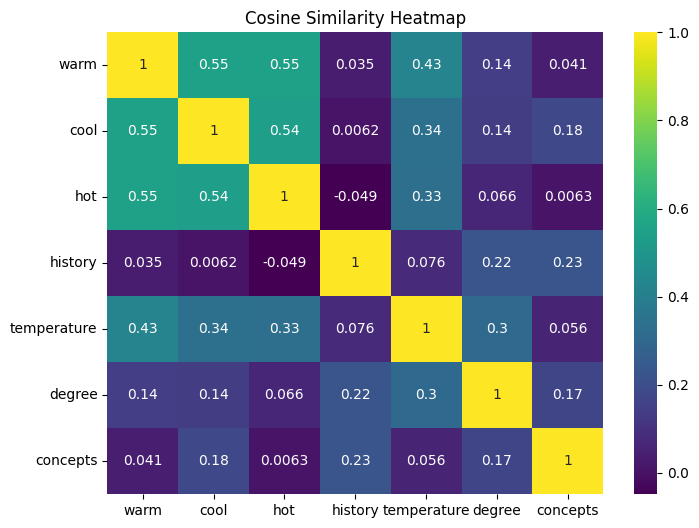

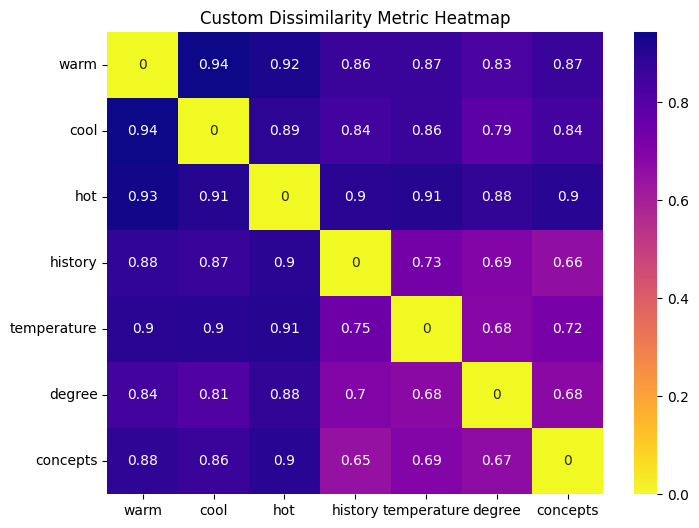

In [181]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_test_words = ["warm", "cool", "hot", "history", "temperature", "degree", "concepts"]

heatmap_embeddings = []
for word in heatmap_test_words:
  heatmap_embeddings.append(wrapper.get_embedding(word))
heatmap_embeddings = np.array(heatmap_embeddings)

cosine_similarity_matrix = np.zeros((len(heatmap_test_words), len(heatmap_test_words)))

for i in range(len(heatmap_test_words)):
  for j in range(len(heatmap_test_words)):
    cosine_similarity_matrix[i, j] = wrapper.calc_cosine_sim(heatmap_embeddings[i], heatmap_embeddings[j])

plt.figure(figsize=(8, 6))
sns.heatmap(cosine_similarity_matrix, annot=True, cmap='viridis',
            xticklabels=heatmap_test_words, yticklabels=heatmap_test_words)
plt.title('Cosine Similarity Heatmap')
plt.show()

dissimilarity_matrix = np.zeros((len(heatmap_test_words), len(heatmap_test_words)))

for i in range(len(heatmap_test_words)):
  for j in range(len(heatmap_test_words)):
    diff = heatmap_embeddings[i] - heatmap_embeddings[j]
    if np.linalg.norm(diff) == 0:
        score = 0.0
    else:
        score = np.linalg.norm(pca.transform([diff])) / np.linalg.norm(diff)
    dissimilarity_matrix[i, j] = score

plt.figure(figsize=(8, 6))
sns.heatmap(dissimilarity_matrix, annot=True, cmap='plasma_r',
            xticklabels=heatmap_test_words, yticklabels=heatmap_test_words)
plt.title('Custom Dissimilarity Metric Heatmap')
plt.show()